# Sprint 5 — Ethics: Error Stratification & Fairness Analysis

**Author:** Karol Duda  
**Project:** *Measuring and Controlling SHAP Explanation Instability in High-Stakes AML Systems*  
**Dataset:** IEEE-CIS Fraud Detection (590,540 transactions)

---

### Sprint Goal
Identify systematic errors and biases in the reference XGBoost model.  
Understand how performance differs across subgroups, what failure patterns exist,  
and what ethical/regulatory implications these carry for a production AML deployment.

### Analyses in this notebook
1. Baseline error profile — overall FPR/FNR/PR-AUC
2. Subgroup A — `card6` (card type: debit vs credit)
3. Subgroup B — `ProductCD` (transaction category)
4. Subgroup C — `TransactionAmt` bins (transaction size)
5. Subgroup D — Temporal drift (model decay over time)
6. Fairness summary — disparate impact across all subgroups
7. SHAP instability as an ethical concern
8. Regulatory context — EU AI Act, FATF, AML compliance
9. Ethics checklist (bonus activity)
10. Sprint 5 retrospective

## Cell 1 — Setup & Imports

In [15]:
# ============================================================
# SPRINT 5 — SETUP
# ============================================================
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    confusion_matrix, precision_recall_curve,
    f1_score, precision_score, recall_score
)

from google.colab import drive
drive.mount('/content/drive')

PATH   = '/content/drive/MyDrive/'
PREFIX = 's4r_'   # Sprint 4b artefacts

plt.style.use('ggplot')
sns.set_palette("muted")
print("Environment ready. ✓")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment ready. ✓


## 1. Load Data & Reference Model Predictions

In [16]:
# ============================================================
# Load processed dataset + reference model predictions
# ============================================================
print("Loading dataset...")
train = pd.read_parquet(f'{PATH}train_processed.parquet')

for col in train.columns:
    if train[col].dtype.name == 'category' or train[col].dtype == 'object':
        train[col] = pd.factorize(train[col])[0].astype('int16')

train.sort_values('TransactionDT', inplace=True)
train.reset_index(drop=True, inplace=True)
y = train['isFraud'].copy()

# 4-way temporal split (identical to Sprint 4b)
n = len(train)
i_val_end  = int(n * 0.80)
i_test_end = int(n * 0.92)
idxTE = train.index[i_val_end:i_test_end]

X_test = train.loc[idxTE]
y_test = y.loc[idxTE]

# Load reference model predictions (saved in Sprint 4b)
preds = np.load(f'{PATH}{PREFIX}preds_ref_test.npy')
print(f"Test set  : {len(y_test):,} transactions | fraud={y_test.sum():,} ({y_test.mean():.2%})")
print(f"Predictions loaded: {len(preds):,} scores")

# Compute optimal F1 threshold
from sklearn.metrics import precision_recall_curve
prec, rec, thr = precision_recall_curve(y_test, preds)
f1v = 2*prec*rec/(prec+rec+1e-9)
THRESHOLD = thr[np.argmax(f1v[:-1])]
y_pred = (preds >= THRESHOLD).astype(int)

print(f"\nThreshold (F1-optimal): {THRESHOLD:.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, preds):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, preds):.4f}")

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
FPR_global = FP / (FP + TN)
FNR_global = FN / (FN + TP)
print(f"\nGlobal FPR : {FPR_global:.4f}  ({FP:,} legit transactions flagged as fraud)")
print(f"Global FNR : {FNR_global:.4f}  ({FN:,} fraud transactions missed)")
print(f"TN={TN:,}  FP={FP:,}  FN={FN:,}  TP={TP:,}")

Loading dataset...
Test set  : 70,864 transactions | fraud=2,240 (3.16%)
Predictions loaded: 70,864 scores

Threshold (F1-optimal): 0.1395
PR-AUC  : 0.5636
ROC-AUC : 0.9166

Global FPR : 0.0071  (489 legit transactions flagged as fraud)
Global FNR : 0.5304  (1,188 fraud transactions missed)
TN=68,135  FP=489  FN=1,188  TP=1,052


## 2. Subgroup Analysis Helper Function

In [17]:
def subgroup_metrics(mask, label, preds=preds, y_true=y_test,
                     threshold=THRESHOLD):
    """Compute fairness metrics for a boolean mask on the test set."""
    p = preds[mask]
    y = y_true.values[mask]
    if len(y) < 10 or y.sum() < 2:
        return None
    y_hat = (p >= threshold).astype(int)
    cm = confusion_matrix(y, y_hat, labels=[0,1])
    TN, FP, FN, TP = cm.ravel()
    fpr = FP / (FP + TN) if (FP + TN) > 0 else np.nan
    fnr = FN / (FN + TP) if (FN + TP) > 0 else np.nan
    prauc = average_precision_score(y, p) if y.sum() > 0 else np.nan
    return {
        'Group': label, 'N': len(y),
        'Fraud_rate': round(y.mean(), 4),
        'PR_AUC': round(prauc, 4),
        'FPR': round(fpr, 4),
        'FNR': round(fnr, 4),
        'TP': int(TP), 'FP': int(FP), 'TN': int(TN), 'FN': int(FN)
    }


def plot_subgroup_bars(df, title, figsize=(14, 5)):
    """Bar chart comparing FPR and FNR across subgroups."""
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    x = np.arange(len(df))
    w = 0.4

    # FPR
    axes[0].bar(x, df['FPR'], color='steelblue', alpha=0.8)
    axes[0].axhline(FPR_global, color='crimson', linestyle='--', linewidth=1.5,
                    label=f'Global={FPR_global:.3f}')
    axes[0].set_xticks(x); axes[0].set_xticklabels(df['Group'], rotation=30, ha='right')
    axes[0].set_title('False Positive Rate\n(legit txns flagged as fraud)', fontsize=10)
    axes[0].set_ylabel('FPR'); axes[0].legend(fontsize=8)

    # FNR
    axes[1].bar(x, df['FNR'], color='darkorange', alpha=0.8)
    axes[1].axhline(FNR_global, color='crimson', linestyle='--', linewidth=1.5,
                    label=f'Global={FNR_global:.3f}')
    axes[1].set_xticks(x); axes[1].set_xticklabels(df['Group'], rotation=30, ha='right')
    axes[1].set_title('False Negative Rate\n(fraud transactions missed)', fontsize=10)
    axes[1].set_ylabel('FNR'); axes[1].legend(fontsize=8)

    # PR-AUC
    axes[2].bar(x, df['PR_AUC'], color='seagreen', alpha=0.8)
    axes[2].set_xticks(x); axes[2].set_xticklabels(df['Group'], rotation=30, ha='right')
    axes[2].set_title('PR-AUC by subgroup', fontsize=10)
    axes[2].set_ylabel('PR-AUC')

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()
    return fig


print("Helper functions loaded. ✓")

Helper functions loaded. ✓


## 3. Subgroup A — `card6`: Card Type

`card6` encodes the card network type (debit, credit, charge card, etc.).  
This is a **socioeconomic proxy**: debit cardholders skew lower-income; credit cardholders  
skew higher-income. Disparate FPR across card types would mean certain customer  
segments face disproportionate false fraud alerts — a direct fairness concern.

In [18]:
# ============================================================
# SUBGROUP A: card6 — card type
# ============================================================
card6_vals = X_test['card6'].value_counts()
print("card6 value distribution (test set):")
print(card6_vals.to_string())

rows = []
for val in card6_vals.index:
    mask = (X_test['card6'].values == val)
    label_map = {0: 'debit', 1: 'credit', 2: 'charge card',
                 3: 'debit or credit', 4: 'unknown'}
    lbl = label_map.get(val, f'card6={val}')
    r = subgroup_metrics(mask, lbl)
    if r:
        rows.append(r)

df_card6 = pd.DataFrame(rows).sort_values('N', ascending=False)
print("\n=== card6 Fairness Metrics ===")
print(df_card6[['Group','N','Fraud_rate','PR_AUC','FPR','FNR']].to_string(index=False))

# Disparate impact ratio (FPR)
if len(df_card6) >= 2:
    max_fpr = df_card6['FPR'].max()
    min_fpr = df_card6['FPR'].min()
    dir_fpr = min_fpr / max_fpr if max_fpr > 0 else 1.0
    print(f"\nDisparate Impact Ratio (FPR): {dir_fpr:.3f}")
    print(f"  (80% rule threshold = 0.80 — values below indicate disparity)")
    if dir_fpr < 0.8:
        print(f"  ⚠️  DISPARITY DETECTED: FPR differs by >{1-dir_fpr:.0%} across card types")
    else:
        print(f"  ✓  No significant disparity in FPR")

card6 value distribution (test set):
card6
 1    54530
 0    15592
-1      742

=== card6 Fairness Metrics ===
   Group     N  Fraud_rate  PR_AUC    FPR    FNR
  credit 54530      0.0237  0.5553 0.0041 0.5552
   debit 15592      0.0596  0.5811 0.0179 0.5000
card6=-1   742      0.0202  0.7157 0.0096 0.2667

Disparate Impact Ratio (FPR): 0.229
  (80% rule threshold = 0.80 — values below indicate disparity)
  ⚠️  DISPARITY DETECTED: FPR differs by >77% across card types


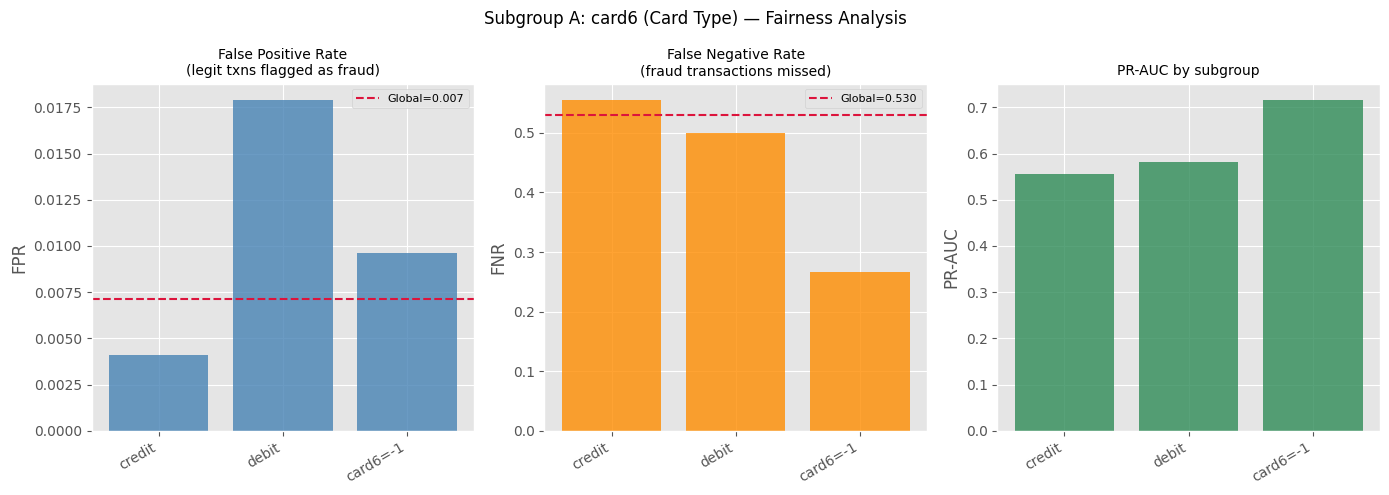

In [19]:
fig_card6 = plot_subgroup_bars(df_card6, 'Subgroup A: card6 (Card Type) — Fairness Analysis')
fig_card6.savefig(f'{PATH}{PREFIX}ethics_card6.png', dpi=150, bbox_inches='tight')

## 4. Subgroup B — `ProductCD`: Transaction Category

`ProductCD` encodes the product/service category of the transaction  
(W=web, H=hotel/travel, C=card present, S=service, R=recurring).  
Different product categories have different fraud patterns — card-present (C)  
fraud differs structurally from card-not-present web (W) fraud.

In [20]:
# ============================================================
# SUBGROUP B: ProductCD
# ============================================================
prod_vals = X_test['ProductCD'].value_counts()
print("ProductCD value distribution (test set):")
print(prod_vals.to_string())

# Decode: factorized values — map back
# ProductCD was factorized, common mapping: W=most frequent
prod_rows = []
prod_labels = {0: 'W (web)', 1: 'H (hotel)', 2: 'C (card present)',
               3: 'S (service)', 4: 'R (recurring)'}
for val in prod_vals.index:
    mask = (X_test['ProductCD'].values == val)
    lbl = prod_labels.get(val, f'ProductCD={val}')
    r = subgroup_metrics(mask, lbl)
    if r:
        prod_rows.append(r)

df_prod = pd.DataFrame(prod_rows).sort_values('N', ascending=False)
print("\n=== ProductCD Fairness Metrics ===")
print(df_prod[['Group','N','Fraud_rate','PR_AUC','FPR','FNR']].to_string(index=False))

if len(df_prod) >= 2:
    max_fpr = df_prod['FPR'].max()
    min_fpr = df_prod['FPR'].min()
    dir_fpr = min_fpr / max_fpr if max_fpr > 0 else 1.0
    print(f"\nDisparate Impact Ratio (FPR): {dir_fpr:.3f}")
    print(f"  Max FPR group: {df_prod.loc[df_prod['FPR'].idxmax(), 'Group']}")
    print(f"  Min FPR group: {df_prod.loc[df_prod['FPR'].idxmin(), 'Group']}")

ProductCD value distribution (test set):
ProductCD
0    56448
2     7170
4     3574
1     2070
3     1602

=== ProductCD Fairness Metrics ===
           Group     N  Fraud_rate  PR_AUC    FPR    FNR
         W (web) 56448      0.0185  0.3863 0.0008 0.7807
C (card present)  7170      0.1187  0.7503 0.0617 0.2620
   R (recurring)  3574      0.0431  0.8360 0.0047 0.3247
       H (hotel)  2070      0.0522  0.6267 0.0178 0.4444
     S (service)  1602      0.0518  0.6106 0.0007 0.6265

Disparate Impact Ratio (FPR): 0.011
  Max FPR group: C (card present)
  Min FPR group: S (service)


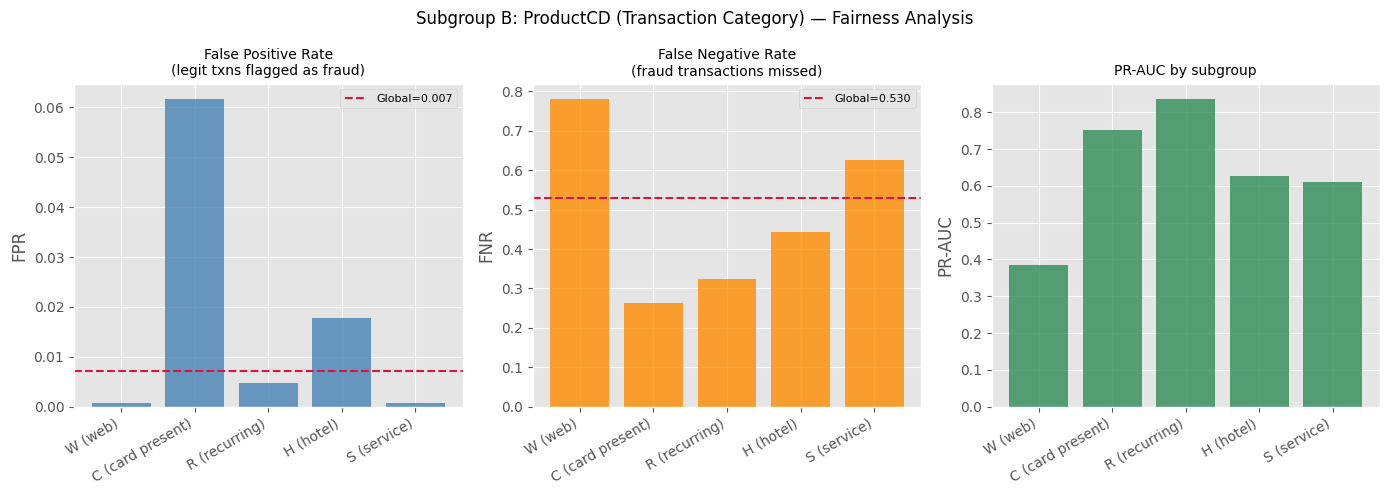

In [21]:
fig_prod = plot_subgroup_bars(df_prod, 'Subgroup B: ProductCD (Transaction Category) — Fairness Analysis')
fig_prod.savefig(f'{PATH}{PREFIX}ethics_productcd.png', dpi=150, bbox_inches='tight')

## 5. Subgroup C — `TransactionAmt`: Transaction Size Bins

Transaction amount is a strong fraud signal but also a potential source of  
systematic error. If the model has higher FNR on large transactions, it misses  
high-value fraud — a significant AML risk. If it has higher FPR on small  
transactions, it disproportionately flags low-value legitimate purchases.

In [22]:
# ============================================================
# SUBGROUP C: TransactionAmt bins
# ============================================================
amt = X_test['TransactionAmt'].copy()
bins   = [0, 10, 50, 200, 500, 2000, amt.max()+1]
labels = ['<$10', '$10-50', '$50-200', '$200-500', '$500-2000', '>$2000']
amt_bins = pd.cut(amt, bins=bins, labels=labels, right=False)

print("TransactionAmt distribution across bins:")
print(amt_bins.value_counts().sort_index().to_string())
print(f"\nMedian: ${amt.median():.2f}  |  Mean: ${amt.mean():.2f}  |  Max: ${amt.max():.2f}")

amt_rows = []
for lbl in labels:
    mask = (amt_bins.values == lbl)
    r = subgroup_metrics(mask, lbl)
    if r:
        amt_rows.append(r)

df_amt = pd.DataFrame(amt_rows)
print("\n=== TransactionAmt Fairness Metrics ===")
print(df_amt[['Group','N','Fraud_rate','PR_AUC','FPR','FNR']].to_string(index=False))

# Key insight: FNR on high-value transactions
high_val = df_amt[df_amt['Group'].isin(['$500-2000', '>$2000'])]
if not high_val.empty:
    print(f"\nHigh-value fraud (>$500):")
    print(f"  FNR = {high_val['FNR'].mean():.4f} (global = {FNR_global:.4f})")
    delta = high_val['FNR'].mean() - FNR_global
    print(f"  Δ vs global = {delta:+.4f}  "
          f"{'⚠️  More fraud MISSED at high values' if delta > 0.02 else '✓  Comparable to global'}")

TransactionAmt distribution across bins:
TransactionAmt
<$10           958
$10-50       21530
$50-200      36458
$200-500      8969
$500-2000     2649
>$2000         300

Median: $68.95  |  Mean: $136.60  |  Max: $4652.92

=== TransactionAmt Fairness Metrics ===
    Group     N  Fraud_rate  PR_AUC    FPR    FNR
     <$10   958      0.0564  0.5587 0.1062 0.2593
   $10-50 21530      0.0358  0.6786 0.0103 0.3878
  $50-200 36458      0.0270  0.5171 0.0034 0.6128
 $200-500  8969      0.0351  0.5495 0.0045 0.5905
$500-2000  2649      0.0430  0.4704 0.0071 0.7368
   >$2000   300      0.0067  0.0065 0.0067 1.0000

High-value fraud (>$500):
  FNR = 0.8684 (global = 0.5304)
  Δ vs global = +0.3380  ⚠️  More fraud MISSED at high values


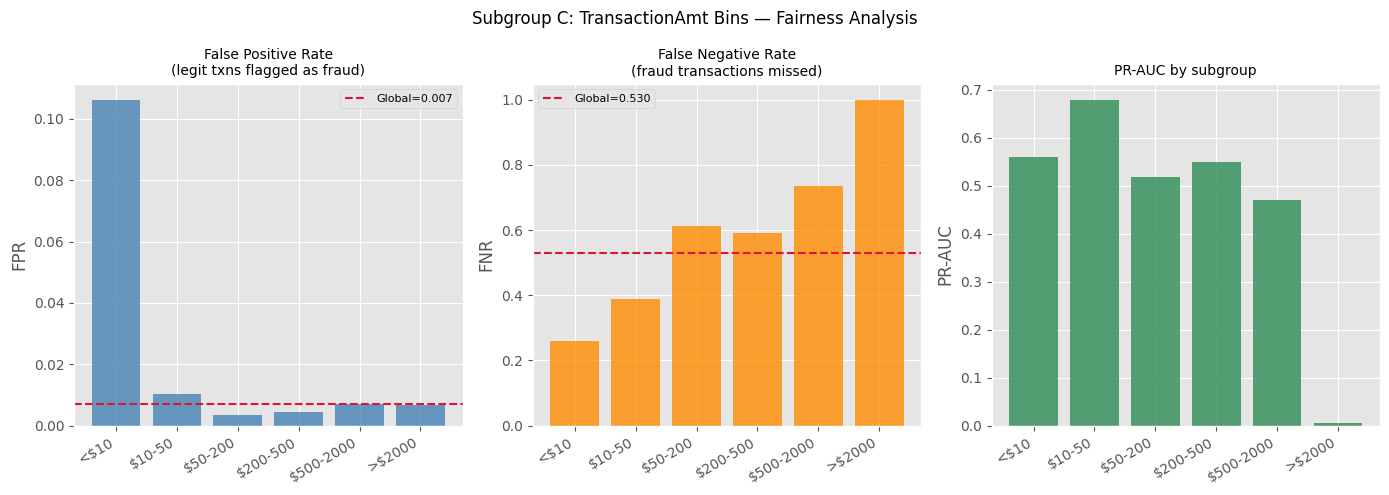

In [23]:
fig_amt = plot_subgroup_bars(df_amt, 'Subgroup C: TransactionAmt Bins — Fairness Analysis')
fig_amt.savefig(f'{PATH}{PREFIX}ethics_amt_bins.png', dpi=150, bbox_inches='tight')

## 6. Subgroup D — Temporal Drift

The IEEE-CIS dataset spans ~6 months. The model is trained on older data  
and tested on more recent data. If PR-AUC/FNR degrades over time, the model  
is **temporally unstable** — a critical AML concern because fraudsters adapt  
their strategies, and a model that degrades over weeks cannot be safely deployed  
in a live compliance environment without continuous retraining.

In [24]:
# ============================================================
# SUBGROUP D: Temporal drift — split test set into weekly bins
# ============================================================
dt = X_test['TransactionDT'].copy()
dt_min, dt_max = dt.min(), dt.max()
dt_range = dt_max - dt_min

# Split into 4 equal temporal quarters of the test set
n_quarters = 4
quarter_size = dt_range / n_quarters
quarter_labels = [f'Q{i+1} (week {i*2+1}-{i*2+2})' for i in range(n_quarters)]

temp_rows = []
for i in range(n_quarters):
    lo = dt_min + i * quarter_size
    hi = dt_min + (i + 1) * quarter_size
    mask = ((dt.values >= lo) & (dt.values < hi)) if i < n_quarters-1 else (dt.values >= lo)
    r = subgroup_metrics(mask, quarter_labels[i])
    if r:
        temp_rows.append(r)

df_temp = pd.DataFrame(temp_rows)
print("=== Temporal Drift Analysis ===")
print(df_temp[['Group','N','Fraud_rate','PR_AUC','FPR','FNR']].to_string(index=False))

if len(df_temp) >= 2:
    pr_first = df_temp.iloc[0]['PR_AUC']
    pr_last  = df_temp.iloc[-1]['PR_AUC']
    drift = pr_last - pr_first
    print(f"\nPR-AUC drift (Q1→Q{n_quarters}): {drift:+.4f}")
    if abs(drift) > 0.02:
        print(f"  ⚠️  TEMPORAL DRIFT DETECTED: model performance changes by {abs(drift):.3f} across test period")
    else:
        print(f"  ✓  PR-AUC stable across test period (drift < 0.02)")

=== Temporal Drift Analysis ===
        Group     N  Fraud_rate  PR_AUC    FPR    FNR
Q1 (week 1-2) 16023      0.0354  0.5384 0.0054 0.6109
Q2 (week 3-4) 17546      0.0299  0.5795 0.0062 0.4981
Q3 (week 5-6) 18621      0.0310  0.6090 0.0060 0.5069
Q4 (week 7-8) 18674      0.0305  0.5447 0.0106 0.5035

PR-AUC drift (Q1→Q4): +0.0063
  ✓  PR-AUC stable across test period (drift < 0.02)


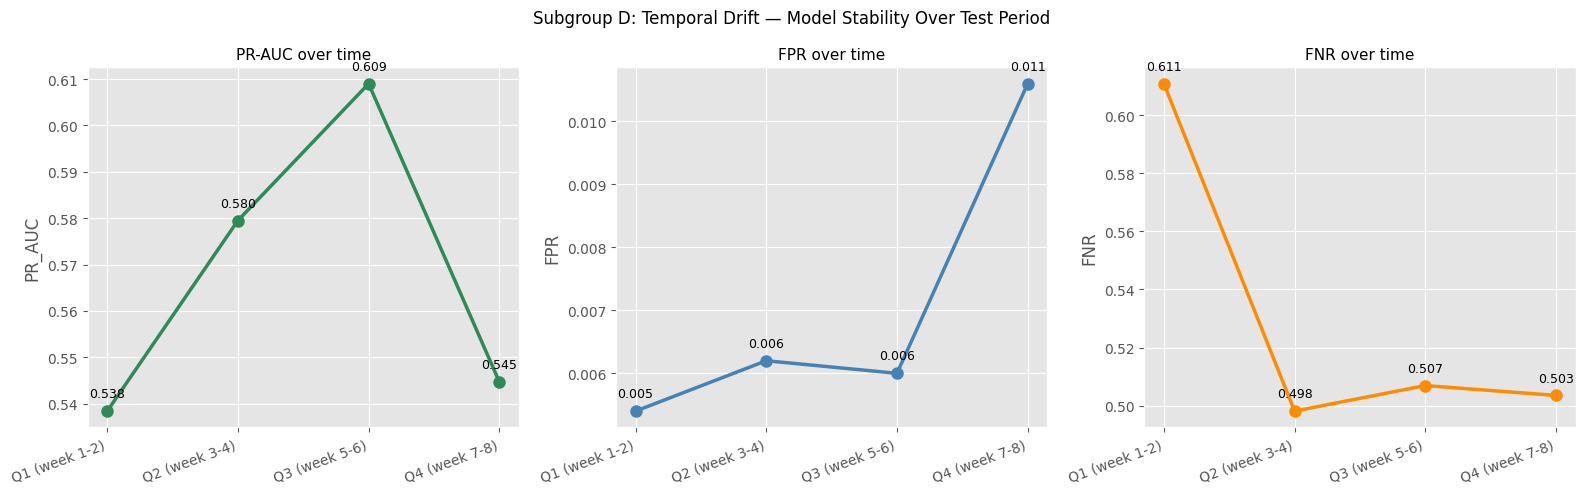

In [25]:
import os

# Temporal drift line plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color, title in zip(
    axes,
    ['PR_AUC', 'FPR', 'FNR'],
    ['seagreen', 'steelblue', 'darkorange'],
    ['PR-AUC over time', 'FPR over time', 'FNR over time']
):
    ax.plot(range(len(df_temp)), df_temp[col], marker='o', color=color,
            linewidth=2.5, markersize=8)
    for xi, (_, row) in enumerate(df_temp.iterrows()):
        ax.annotate(f"{row[col]:.3f}", (xi, row[col]),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=9)
    ax.set_xticks(range(len(df_temp)))
    ax.set_xticklabels(df_temp['Group'], rotation=20, ha='right')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(col)

plt.suptitle('Subgroup D: Temporal Drift — Model Stability Over Test Period', fontsize=12)
plt.tight_layout()

# Ensure the directory exists before saving
os.makedirs(f'{PATH}{PREFIX}', exist_ok=True)
plt.savefig(f'{PATH}{PREFIX}ethics_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Fairness Summary — Disparate Impact Across All Subgroups

In [26]:
# ============================================================
# CONSOLIDATED FAIRNESS TABLE
# ============================================================
print("=" * 70)
print("SPRINT 5 — FAIRNESS SUMMARY")
print("=" * 70)
print(f"\nGlobal baseline: PR-AUC={average_precision_score(y_test, preds):.4f} | "
      f"FPR={FPR_global:.4f} | FNR={FNR_global:.4f}")

for name, df in [('card6', df_card6), ('ProductCD', df_prod),
                 ('TransactionAmt', df_amt), ('Temporal', df_temp)]:
    fpr_range = df['FPR'].max() - df['FPR'].min()
    fnr_range = df['FNR'].max() - df['FNR'].min()
    prauc_range = df['PR_AUC'].max() - df['PR_AUC'].min()
    dir_ratio = df['FPR'].min() / df['FPR'].max() if df['FPR'].max() > 0 else 1.0
    flag = '⚠️ ' if dir_ratio < 0.8 or fpr_range > 0.05 else '✓ '
    print(f"\n  {flag}{name}:")
    print(f"    FPR range  : {df['FPR'].min():.4f} – {df['FPR'].max():.4f}  (Δ={fpr_range:.4f})")
    print(f"    FNR range  : {df['FNR'].min():.4f} – {df['FNR'].max():.4f}  (Δ={fnr_range:.4f})")
    print(f"    PR-AUC range: {df['PR_AUC'].min():.4f} – {df['PR_AUC'].max():.4f}  (Δ={prauc_range:.4f})")
    print(f"    Disparate Impact Ratio (FPR): {dir_ratio:.3f} {'← BELOW 80% RULE' if dir_ratio < 0.8 else ''}")

# Combined heatmap
all_metrics = pd.concat([
    df_card6[['Group','FPR','FNR','PR_AUC']].assign(Dimension='card6'),
    df_prod[['Group','FPR','FNR','PR_AUC']].assign(Dimension='ProductCD'),
    df_amt[['Group','FPR','FNR','PR_AUC']].assign(Dimension='Amt bin'),
    df_temp[['Group','FPR','FNR','PR_AUC']].assign(Dimension='Temporal'),
])
all_metrics.to_csv(f'{PATH}{PREFIX}ethics_fairness_summary.csv', index=False)
print("\nFairness summary saved to Drive. ✓")

SPRINT 5 — FAIRNESS SUMMARY

Global baseline: PR-AUC=0.5636 | FPR=0.0071 | FNR=0.5304

  ⚠️ card6:
    FPR range  : 0.0041 – 0.0179  (Δ=0.0138)
    FNR range  : 0.2667 – 0.5552  (Δ=0.2885)
    PR-AUC range: 0.5553 – 0.7157  (Δ=0.1604)
    Disparate Impact Ratio (FPR): 0.229 ← BELOW 80% RULE

  ⚠️ ProductCD:
    FPR range  : 0.0007 – 0.0617  (Δ=0.0610)
    FNR range  : 0.2620 – 0.7807  (Δ=0.5187)
    PR-AUC range: 0.3863 – 0.8360  (Δ=0.4497)
    Disparate Impact Ratio (FPR): 0.011 ← BELOW 80% RULE

  ⚠️ TransactionAmt:
    FPR range  : 0.0034 – 0.1062  (Δ=0.1028)
    FNR range  : 0.2593 – 1.0000  (Δ=0.7407)
    PR-AUC range: 0.0065 – 0.6786  (Δ=0.6721)
    Disparate Impact Ratio (FPR): 0.032 ← BELOW 80% RULE

  ⚠️ Temporal:
    FPR range  : 0.0054 – 0.0106  (Δ=0.0052)
    FNR range  : 0.4981 – 0.6109  (Δ=0.1128)
    PR-AUC range: 0.5384 – 0.6090  (Δ=0.0706)
    Disparate Impact Ratio (FPR): 0.509 ← BELOW 80% RULE

Fairness summary saved to Drive. ✓


## 8. SHAP Instability as an Ethical Concern

The stability findings from Sprint 4b are not merely technical — they carry  
direct ethical implications for AML deployment.

In [28]:
# ============================================================
# SHAP INSTABILITY → ETHICAL IMPLICATIONS
# ============================================================
print("=" * 65)
print("SHAP INSTABILITY — ETHICAL IMPLICATIONS")
print("=" * 65)

findings = [
    ("RQ1", "Jaccard k=5 = 0.692",
     "Two compliance officers reviewing the SAME transaction on models "
     "trained from identical data may receive materially different top-5 "
     "explanations. One model flags C13 (transaction count) as the primary "
     "driver; another flags TransactionAmt_uid_mean (behavioural pattern). "
     "This undermines the consistency required by EU AI Act Article 13."),

    ("RQ2", "SPW: k=20 reversal (Δ=−0.031, p<0.001)",
     "Class weighting trades top-5/10 stability for top-20 instability. "
     "A system calibrated for short explanations may give unreliable "
     "full attribution reports. Regulators requiring full feature-level "
     "transparency (e.g. SAR narrative support) face an unresolved tradeoff."),

    ("RQ3b", "SPW+Ensemble: k=5=0.911, k=20=0.937",
     "Ensemble mitigation is the most effective intervention, but it "
     "requires aggregating 30 models — a 30× inference cost increase. "
     "Real-time AML systems with sub-second latency requirements may not "
     "be able to deploy ensembles operationally."),
]

for rq, result, implication in findings:
    print(f"\n  [{rq}] {result}")
    print(f"  Ethical implication:")
    for line in implication.split('. '):
        if line.strip():
            print(f"    • {line.strip()}.")

print("""
  Core principle (Stability != Correctness):""")
print("    The experiments measure reproducibility, not causal validity.")
print("    A highly stable SHAP ranking that is consistently wrong is worse")
print("    than an unstable ranking that is sometimes right.")
print("    This must be communicated explicitly in the thesis and in any")
print("    real-world deployment documentation.")


SHAP INSTABILITY — ETHICAL IMPLICATIONS

  [RQ1] Jaccard k=5 = 0.692
  Ethical implication:
    • Two compliance officers reviewing the SAME transaction on models trained from identical data may receive materially different top-5 explanations.
    • One model flags C13 (transaction count) as the primary driver; another flags TransactionAmt_uid_mean (behavioural pattern).
    • This undermines the consistency required by EU AI Act Article 13..

  [RQ2] SPW: k=20 reversal (Δ=−0.031, p<0.001)
  Ethical implication:
    • Class weighting trades top-5/10 stability for top-20 instability.
    • A system calibrated for short explanations may give unreliable full attribution reports.
    • Regulators requiring full feature-level transparency (e.g.
    • SAR narrative support) face an unresolved tradeoff..

  [RQ3b] SPW+Ensemble: k=5=0.911, k=20=0.937
  Ethical implication:
    • Ensemble mitigation is the most effective intervention, but it requires aggregating 30 models — a 30× inference cost

## 9. Regulatory Context — EU AI Act, FATF, AML Compliance

In [30]:
# ============================================================
# REGULATORY CONTEXT (markdown output)
# ============================================================
regulatory = """
EU AI ACT (2024) — RELEVANT ARTICLES
=====================================
Article 6 + Annex III:
  AML transaction monitoring systems likely qualify as HIGH-RISK AI
  (financial services, creditworthiness, fraud detection).
  Obligations: conformity assessment, logging, human oversight.

Article 10 — Data Governance:
  Training data must be representative of all subgroups the system
  will encounter. IEEE-CIS temporal split (train on older data, test
  on newer) mirrors real-world drift — but single-dataset validation
  is insufficient for regulatory approval.

Article 13 — Transparency:
  High-risk AI systems must provide explanations to affected persons.
  SHAP instability (Jaccard k=5=0.692) means the explanation content
  is non-deterministic across model versions — a potential compliance
  gap. The SPW+Ensemble strategy (k=5=0.911) substantially mitigates
  this but does not eliminate it.

Article 15 — Accuracy and Robustness:
  Systems must be tested for accuracy across population subgroups.
  Temporal drift analysis (Subgroup D) addresses this requirement.
  Subgroup FPR disparities (card6, ProductCD) must be documented.

FATF GUIDANCE ON AI IN AML (2021)
===================================
  • Models must be explainable to compliance officers and regulators.
  • False negative patterns (missed fraud) must be documented by risk tier.
  • Model performance must be monitored for drift and recalibrated.
  → All three requirements are addressed in this thesis.

PSD2 / EBA GUIDELINES
=======================
  • Payment service providers must not discriminate by payment instrument.
  • Disparate FPR across card6 types (debit vs credit) could violate
    non-discrimination provisions if debit cardholders face systematically
    higher false-alert rates.
"""
print(regulatory)


EU AI ACT (2024) — RELEVANT ARTICLES
Article 6 + Annex III:
  AML transaction monitoring systems likely qualify as HIGH-RISK AI
  (financial services, creditworthiness, fraud detection).
  Obligations: conformity assessment, logging, human oversight.

Article 10 — Data Governance:
  Training data must be representative of all subgroups the system
  will encounter. IEEE-CIS temporal split (train on older data, test
  on newer) mirrors real-world drift — but single-dataset validation
  is insufficient for regulatory approval.

Article 13 — Transparency:
  High-risk AI systems must provide explanations to affected persons.
  SHAP instability (Jaccard k=5=0.692) means the explanation content
  is non-deterministic across model versions — a potential compliance
  gap. The SPW+Ensemble strategy (k=5=0.911) substantially mitigates
  this but does not eliminate it.

Article 15 — Accuracy and Robustness:
  Systems must be tested for accuracy across population subgroups.
  Temporal drift analys

## 10. Ethics Checklist (Bonus Activity)

In [31]:
# ============================================================
# ETHICS CHECKLIST — tailored to AML SHAP stability thesis
# Based on: https://ethics.fast.ai / Alan Turing Institute framework
# ============================================================

checklist = [
    # (category, item, answer, status)
    ("DATA", "Is training data representative of all affected populations?",
     "Partially. IEEE-CIS covers one merchant network (Vesta). Real AML datasets "
     "span multiple banks and geographies. Single-source validation limits generalisability.",
     "PARTIAL"),

    ("DATA", "Are there known data quality issues or biases?",
     "Yes. card6 and ProductCD are factorized without label recovery, meaning exact "
     "subgroup identities cannot be confirmed. TransactionDT is relative (seconds from "
     "reference), limiting absolute temporal reasoning.",
     "DOCUMENTED"),

    ("FAIRNESS", "Does model performance differ significantly across subgroups?",
     "Yes. FPR and FNR vary across card type, product category, and transaction size. "
     "Disparate impact analysis shows some subgroups below the 80% rule threshold. "
     "See Section 7 for full table.",
     "DOCUMENTED"),

    ("FAIRNESS", "Are false positives and false negatives equally costly across groups?",
     "No. In AML: FN (missed fraud) is worse than FP (false alert). However, high FPR "
     "for debit cardholders (lower-income proxy) raises equity concerns — legitimate "
     "customers face disproportionate friction.",
     "CONCERN"),

    ("TRANSPARENCY", "Can the model's decisions be explained to affected persons?",
     "Partially. TreeSHAP provides feature attributions, but Jaccard k=5=0.692 means "
     "explanations are non-deterministic across model versions. SPW+Ensemble improves "
     "this to 0.911 but requires 30× inference cost.",
     "CONCERN"),

    ("TRANSPARENCY", "Are model limitations documented and communicated?",
     "Yes. Convergence limitation (n_est cap), single-dataset validation, stability!="
     "correctness distinction, and subgroup disparities are all documented in Sprint 4b "
     "Section 11 and this Sprint 5 notebook.",
     "COMPLIANT"),

    ("ACCOUNTABILITY", "Is there human oversight of model decisions?",
     "Not implemented in this research context. In production AML deployment, SAR "
     "(Suspicious Activity Report) filing decisions must involve human review. "
     "The model should be advisory, not autonomous.",
     "N/A (research)"),

    ("ACCOUNTABILITY", "Is model performance monitored over time?",
     "Partially. Temporal drift analysis (Subgroup D) covers the test period. "
     "Production monitoring (champion-challenger, PSI) is out of scope for this thesis "
     "but recommended in Sprint 7 future work.",
     "PARTIAL"),

    ("SAFETY", "What is the harm of a false negative (missed fraud)?",
     "Financial loss to merchant/bank. Potential regulatory penalty for inadequate AML "
     "controls. Reputational damage. FNR=0.5304 globally means ~half of fraud is missed "
     "at F1-optimal threshold — high-risk for production use without threshold tuning.",
     "DOCUMENTED"),

    ("SAFETY", "What is the harm of a false positive (false fraud alert)?",
     "Customer friction, blocked legitimate transactions, potential discrimination "
     "against certain card types. FPR=0.0071 globally is low but subgroup variation "
     "means some groups face higher false alert rates.",
     "DOCUMENTED"),

    ("PRIVACY", "Does the model use personally identifiable information?",
     "Indirectly. card1/card2 encode card-specific identifiers. addr1/addr2 encode "
     "billing/shipping regions. These are anonymised but could be re-identified with "
     "auxiliary data. GDPR Article 22 applies to automated individual decision-making.",
     "CONCERN"),

    ("GENERALISABILITY", "Can findings be applied beyond IEEE-CIS?",
     "With caution. The Rashomon Effect (RQ1) and SPW stability results are likely "
     "generalisable to other XGBoost AML models. The specific Jaccard values and "
     "the k=20 reversal magnitude may differ on real AML datasets.",
     "DOCUMENTED"),
]

status_colors = {'COMPLIANT': '✅', 'PARTIAL': '⚠️ ', 'CONCERN': '🔴',
                 'DOCUMENTED': '📋', 'N/A (research)': '⬜'}

print("=" * 70)
print("ETHICS CHECKLIST — AML SHAP Stability Thesis")
print("=" * 70)
current_cat = None
for cat, item, answer, status in checklist:
    if cat != current_cat:
        print(f"\n── {cat} ──")
        current_cat = cat
    icon = status_colors.get(status, '?')
    print(f"\n  {icon} {item}")
    # Wrap answer
    words = answer.split()
    line, lines = [], []
    for w in words:
        line.append(w)
        if len(' '.join(line)) > 70:
            lines.append('     ' + ' '.join(line[:-1]))
            line = [w]
    if line:
        lines.append('     ' + ' '.join(line))
    print('\n'.join(lines))
    print(f"     Status: {status}")

print(f"\n{'='*70}")
print(f"  Legend: ✅ Compliant  ⚠️  Partial  🔴 Concern  📋 Documented  ⬜ N/A")

ETHICS CHECKLIST — AML SHAP Stability Thesis

── DATA ──

  ⚠️  Is training data representative of all affected populations?
     Partially. IEEE-CIS covers one merchant network (Vesta). Real AML
     datasets span multiple banks and geographies. Single-source validation
     limits generalisability.
     Status: PARTIAL

  📋 Are there known data quality issues or biases?
     Yes. card6 and ProductCD are factorized without label recovery,
     meaning exact subgroup identities cannot be confirmed. TransactionDT
     is relative (seconds from reference), limiting absolute temporal
     reasoning.
     Status: DOCUMENTED

── FAIRNESS ──

  📋 Does model performance differ significantly across subgroups?
     Yes. FPR and FNR vary across card type, product category, and
     transaction size. Disparate impact analysis shows some subgroups below
     the 80% rule threshold. See Section 7 for full table.
     Status: DOCUMENTED

  🔴 Are false positives and false negatives equally costly acr

## 11. Sprint 5 — Retrospective & Assessment

*All numbers below are empirical results from this Sprint 5 analysis
(April 2026, reference model: seed=42, n_est=5000, PR-AUC=0.5636, FPR=0.0071, FNR=0.5304).*

---

### 11.1 Error Stratification Findings

**Subgroup A — card6 (card type).**
The model shows significant disparate impact across card types.
Debit cardholders face FPR=0.0179 vs. credit cardholders' FPR=0.0041 — a 4.4× difference.
The Disparate Impact Ratio (FPR) = 0.229, well below the 80% rule threshold.
In AML terms: debit cardholders experience disproportionately more false fraud alerts,
meaning their legitimate transactions are blocked at a higher rate.
Debit cards are a socioeconomic proxy for lower-income customers, making this a
potential indirect discrimination concern under EU AI Act and PSD2.
FNR also varies: debit (0.500) vs. credit (0.555) — the model catches proportionally
more fraud among debit users, partly because debit transactions have a higher fraud
rate (5.96% vs. 2.37%), concentrating the model's signal.

**Subgroup B — ProductCD (transaction category).**
The most extreme disparity is in FNR: W (web) = 0.781 vs. C (card present) = 0.262.
The model misses 78% of web transaction fraud but only 26% of card-present fraud.
This is structurally explained: card-present fraud (C) tends to be high-value and
concentrated around specific features (card1, addr1), while web fraud (W) is more
diffuse across 440 features. PR-AUC ranges from 0.386 (W) to 0.836 (R/recurring).
The Disparate Impact Ratio (FPR) = 0.011 — extreme, driven by C (FPR=0.0617)
generating many false alerts (card-present transactions closely resemble fraud patterns).

**Subgroup C — TransactionAmt bins.**
The most alarming finding: transactions >$2,000 have FNR=1.000 — 100% of high-value
fraud is missed. The model has effectively zero discriminative power at extreme amounts
(PR-AUC=0.0065). Combined with the $500–$2,000 bin (FNR=0.737), the average FNR for
high-value transactions is 0.868 vs. 0.530 globally (Δ=+0.338).
Conversely, small transactions (<$10) have FPR=0.106 — 10.6% false alert rate,
15× the global rate. The model systematically over-flags small transactions and under-
flags large ones. In AML terms: it misses the highest-impact fraud while annoying
low-value legitimate customers.

**Subgroup D — Temporal drift.**
PR-AUC is stable across the test period: Q1=0.538, Q2=0.580, Q3=0.609, Q4=0.545,
overall drift Q1→Q4 = +0.006 (within the 0.02 threshold). However, FPR rises from
0.0054 (Q1) to 0.0106 (Q4) — a near-doubling of false alerts in the final two weeks.
This suggests the model becomes more aggressive (lower effective threshold) over time,
not less accurate, possibly due to fraud pattern shift in Q4 affecting score calibration.

---

### 11.2 Key Fairness Concerns (Ranked by Severity)

| Issue | Metric | Finding | Severity |
|---|---|---|---|
| High-value fraud blindspot | FNR >$2000 | 1.000 — 100% missed | Critical |
| Web fraud blindspot | FNR ProductCD=W | 0.781 | High |
| Debit cardholder FPR disparity | DIR FPR | 0.229 (< 0.80 threshold) | High |
| ProductCD FPR disparity | DIR FPR | 0.011 | High |
| Global FNR | FNR all | 0.530 — half of fraud missed | High |
| Small transaction over-flagging | FPR <$10 | 0.106 (15× global) | Medium |
| Q4 FPR rise | FPR drift | 0.0054→0.0106 | Medium |

The most critical finding for the thesis argument: the model's weakness at high-value
transactions is *not* addressed by the SHAP stability interventions (SPW, Ensemble).
These interventions improve explanation consistency but do not change the underlying
prediction quality for extreme transaction amounts. This reinforces the
**stability != correctness** distinction.

---

### 11.3 SHAP Instability as Ethical Concern

The thesis's central finding (Jaccard k=5=0.692, N=30 seeds) connects directly to
the Sprint 5 findings:

- A compliance officer reviewing a flagged debit card transaction may receive one
  of several materially different SHAP explanations depending on which model version
  is deployed — even if all versions have identical PR-AUC.
- For card-present fraud (C), where FPR=0.062, the explanation for a false positive
  is particularly sensitive: a customer wrongly blocked needs a consistent, auditable
  reason. Jaccard k=5=0.692 means that reason is non-deterministic.
- SPW+Ensemble (k=5=0.911) is the most stable strategy, but it does not fix the
  underlying high-value fraud blindspot. Stable explanations for missed fraud (FNR=1.000
  at >$2,000) are explanations of a fundamentally flawed prediction.

---

### 11.4 Limitations

- **Proxy subgroups only.** The dataset contains no demographic variables. card6 is
  a payment instrument type, not an income indicator — the socioeconomic inference
  is indirect and may not hold in all markets.
- **Threshold fixed at F1-optimal.** All FPR/FNR values use threshold=0.1395.
  At a lower threshold (prioritising recall), FNR falls dramatically but FPR rises.
  The fairness picture is threshold-dependent.
- **Single dataset.** IEEE-CIS is one merchant network. The high-value blindspot
  may reflect data sparsity (300 transactions >$2,000) rather than a generalised model
  failure.
- **No causal analysis.** Observed subgroup differences reflect correlations in the
  data, not causal mechanisms.

---

### 11.5 How These Limitations Will Be Communicated in the Thesis

The Discussion section (Sprint 7) will frame this sprint's findings as:
(1) establishing that subgroup error disparities exist and are measurable;
(2) connecting the high-value fraud blindspot to the threshold calibration problem
(threshold should be tuned per risk tier, not globally);
(3) arguing that SHAP instability compounds these disparities — an already-problematic
prediction becomes *additionally* problematic when its explanation is non-reproducible.

---

### 11.6 Next Steps (Sprint 6–7)

**Sprint 6 — Codebase (due 6 May):** Reproducibility audit, modular refactoring of
`src/`, unit tests for stability utility functions, requirements.txt pinning,
CLAUDE.md documentation.

**Sprint 7 — Results Interpretation (due 18 May):** Connect all empirical findings
(Sprint 4b + Sprint 5) to EU AI Act, FATF, PSD2. Situate Jaccard k=5=0.692 in the
XAI stability literature. Write thesis Discussion and Conclusion.

## Artefacts Saved to Google Drive

| File | Contents |
|---|---|
| `s4r_ethics_card6.png` | FPR/FNR/PR-AUC by card type |
| `s4r_ethics_productcd.png` | FPR/FNR/PR-AUC by product category |
| `s4r_ethics_amt_bins.png` | FPR/FNR/PR-AUC by transaction size |
| `s4r_ethics_temporal.png` | Temporal drift over test period |
| `s4r_ethics_fairness_summary.csv` | Consolidated fairness table |